# Calculating Yields to Maturity (YTM)

This notebook calculates the Yield to Maturity (YTM) for the 304 bonds downloaded from DropBox. To achieve this, we will develop three essential functions:

1. <font color='green'>bond_pv</font>: Calculates the present value of a bond.  
2. <font color='green'>single_newton_raphson</font>: Uses the Newton-Raphson technique to find the root of a function by updating each guess with an error scaled by the derivative.  
3. <font color='green'>calc_ytm</font>: Calculates the bond's yield to maturity.

The primary function, <font color='green'>calc_ytm</font>, relies on the first two as helper functions. Specifically, <font color='green'>calc_ytm</font> calls <font color='green'>single_newton_raphson</font> and that in turn calls <font color='green'>bond_pv</font>. Although <font color='green'>calc_ytm</font> is designed for this single purpose, both <font color='green'>bond_pv</font> and <font color='green'>single_newton_raphson</font> are built for multi-purpose and are used in future chapters. For instance, <font color='green'>bond_pv</font> is used to estimate how changes in interest rates affect bond prices.

Consistent with previous chapters, these functions allow users to focus on the financial topics without needing a deep understanding of the material in preceding chapters.

## Importing libraries, modules, and functions
As in earlier chapters of the volume, modules that are included in the standard Python library are imported. When necessary, other modules or libraries are installed before they are imported.$^{1}$

```
import sys
import requests
from types import ModuleType
from datetime import datetime, date

try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
```
---


$^{1}$For more information on <font color='green'>try</font> and <font color='green'>except</font> statements, see “<a href='https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/Control_Statements.html#the-try-and-except'>Control Statements</a>.”

In [1]:
# Import OS to interact with local computer operating system
import os
import sys
import requests
from types import ModuleType
# Import the datetime and date classes from the datetime module for working with dates.
from datetime import datetime, date
# Last calendar day of the month and day of the week for first day
import calendar
# Import the NumPy library for numerical operations, commonly aliased as np.
try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np

# Import the pandas library for data manipulation and analysis, aliased as pd.
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd

## Adding a custom module and importing functions
The notebook utilizes the custom module, **module_basic_concepts_fixed_income**, sourced from Dropbox and named **basic_concepts_fixed_income**. This module provides three core functions to streamline the focus on financial concepts:

* **accrued_interest** (Chapter Two): This function calculates the accrued interest on a settlement date and is used to calculate transaction prices of bonds.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/accrued_interest.html#accrued-interest-is-a-helper-function-that-calculates-accrued-interest)  

* **create_payoff_matrix** (This Chapter): This function calculates the payoff matrix required to bootstrap the term structure with coupon bonds.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/create_payoff_matrix.html)</a>

* **bond_pay_data** (Chapter Three): Returns the payment dates and amounts.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/bond_pay_data.html#bond-pay-data-helper-function)

The module also contains various supporting helper functions, and it automatically manages the import and, if required, installation of necessary libraries and modules. This structure allows the user to concentrate fully on financial principles rather than complex Python implementation details.

The final imported function is <font color='green'>one_y_axis</font> that plots the yields to maturity of the 304 bonds.

```
from basic_concepts_fixed_income import (accrued_interest,
                                         create_payoff_matrix,
                                         bond_pay_data,
                                         one_y_axis)
```





In [2]:
# Define the URL of the Python module to be downloaded from Dropbox.
# The 'dl=1' parameter in the URL forces a direct download of the file content.
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=87sztshr&dl=1'
module_name='basic_concepts_fixed_income'
# Send an HTTP GET request to the URL and store the server's response.
try:
  response=requests.get(url)
  # Raise an exception for bad status codes (like 404 Not Found)
  response.raise_for_status()
  module= ModuleType(module_name)
  #Code contained in response.text executed
  exec(response.text, module.__dict__)
  # Module added to sys
  sys.modules[module_name]=module
except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")
# Open the local file in "write binary" ('wb') mode and save the downloaded content.
# Using a 'with' statement ensures the file is properly closed after writing.

# Now that 'basic_concepts_ficed_income' exists in the notebook, import the specific functions
from basic_concepts_fixed_income import(accrued_interest,
                                        create_payoff_matrix,
                                        bond_pay_data,
                                        one_y_axis)

## Downloading the data for the 304 bonds

In [3]:
#The full file path.
url='https://www.dropbox.com/scl/fi/lgnaj41bt8o9sv5a63rr1/\
bond_data_jan21_2025.xlsx?rlkey=twjzkcqo0g2ahvot78518ti4x&st=ihc5feog&dl=1'
print(f"Attempting to load data from: {url}")

#Load the data from Excel, using the first column as the index.
try:
    bond_data = pd.read_excel(url, index_col=0,sheet_name='Fidelity Data')

    # Display the first and last 5 rows of the loaded DataFrame to verify it worked..
    display(bond_data)

except FileNotFoundError:
    print("\nERROR: File not found.")
    print("Please check that the 'folder' and 'file' variables are spelled correctly'\
' and that the file exists in that location.")

Attempting to load data from: https://www.dropbox.com/scl/fi/lgnaj41bt8o9sv5a63rr1/bond_data_jan21_2025.xlsx?rlkey=twjzkcqo0g2ahvot78518ti4x&st=ihc5feog&dl=1


,Description,Coupon,Price Bid,Price Ask,Bid Size,Ask Size
Maturity Date,,,,,,
2025-01-28,UNITED STATES TREAS BILLS ZERO CPN 0.000...,0.000,99.929,99.930,100000,100000
2025-01-30,UNITED STATES TREAS BILLS ZERO CPN 0.000...,0.000,99.906,99.907,40000,40000
2025-01-31,UNITED STATES TREAS SER U-2025 1.3750...,1.375,99.921,99.934,60000,60000
2025-01-31,UNITED STATES TREAS SER AW-2025 4.1250...,4.125,99.988,99.997,60000,60000
2025-01-31,UNITED STATES TREAS SER G-2025 2.5000...,2.500,99.953,99.965,60000,60000
...,...,...,...,...,...,...
2029-11-30,UNITED STATES TREAS SER AG-2029 4.1250...,4.125,98.910,98.914,100000,100000
2029-11-30,UNITED STATES TREAS SER S-2029 3.8750...,3.875,97.763,97.782,40000,40000
2029-12-31,UNITED STATES TREAS SER T-2029 3.8750...,3.875,97.734,97.738,65000,65000


## The <font color='green'>bond_pv</font> function

### Calculating present value and derivatives

The <font color='green'>bond_pv_function</font> is used to compute a bond's present value, as well as its derivatives with respect to the interest rates discounting the cash flows. Although a single discount rate is sufficient for calculating the yield to maturity, this function supports the use of multiple rates. A feature that enables the calculation of present values with estimates of the term structure of interest rates.


The function accepts three arguments:

* **<font color='green'>rates</font>**: This can be a single numerical value (e.g., 0.05), often used in yield-to-maturity calculations, or an iterable (e.g., [0.04, 0.05]) representing the term structure for present value estimation.
* **<font color='green'>data_dict</font>**: A dictionary, typically returned by <font color='green'>bond_pay_data</font>, containing bond payment dates and amounts. It may optionally include the settlement date, with keys \`paydata\` and \`settlement\`.  
* **<font color='green'>settlement</font>**: This argument specifies the settlement date and defaults to the current date if not provided within <font color='green'>data_dict</font> or specified as an argument.

#### Present value calculation

The function uses NumPy arrays for <font color='green'>rates</font>, <font color='green'>pay_dates</font>, and <font color='green'>payments</font>. The present value of each payment is calculated and stored in the <font color='green'>pv_payments</font> array, the sum is the bond's total present value.

The time to each payment (<font color='green'>pay_dates</font>) is calculated in a vectorized manner by converting the date objects (<font color='green'>pay_data[0]</font> and <font color='green'>settlement</font>) to NumPy datetime64 data types:$^{2}$

```
pay_dates = (np.array(pay_data[0], dtype='datetime64[D]')
             - np.datetime64(settlement)).astype(float) / 365.25

pv_payments = np.exp(-rates * pay_dates) * payments

value = np.sum(pv_payments)
```

#### Derivative Calculation

The first and second derivatives are computed.

**First Derivative:** At each payment date, the derivative is found by multiplying <font color='green'>pay_dates</font> by the present value factor at those dates (or, equivalently, <font color='green'>pay_dates</font> times $e$ raised to the power of the product of <font color='green'>rates</font> and <font color='green'>pay_dates</font>). The sum of this array yields the bond's first derivative.

**Second Derivative:** The second derivative is calculated as the sum of the present value factors multiplied by the payment dates squared.

The calculation uses the following NumPy operations:

```
derivatives_array = -pay_dates * pv_payments

# First derivative
first_derivative = np.sum(derivatives_array)

# Second derivative
second_derivative = np.sum(-pay_dates * derivatives_array)
```

The function returns the calculated present value, the first derivative, and the second derivative:

```
return value, first_derivative, second_derivative
```


---

$^{2}$ [See A Quick Introduction To Manipulating Dates](https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/Manipulating_Dates.html#numpy-datetime64-object).

In [4]:
def bond_pv(rates=None, data_dict=None, settlement=None):
  '''Calculates a bond's present value, and its first and second derivatives.

  This function prices a bond by discounting its future cash flows using a
  provided set of continuously compounded interest rates. It also computes the
  first and second derivatives of the present value with respect to the rates,
  which are fundamental inputs for calculating risk measures like dollar duration
  and convexity.

  The time to payment is calculated using an Actual/365.25 day-count convention.
  If the provided array of rates is shorter than the number of payments, the
  last rate is used to extrapolate for all subsequent payments.

  Args:
      rates (float or np.ndarray): The continuously compounded discount rate or an
          array of rates. If a single float is provided, it's applied to all
          cash flows.
      data_dict (dict): A dictionary that must contain the bond's payment data.
          It can optionally specify the settlement date.
          - 'pay_data' (tuple): A required tuple of two NumPy arrays:
            (payment_dates, payment_amounts).
          - 'settlement' (datetime.date): An optional valuation date.
      settlement (datetime.date, optional): The valuation date. This argument is
          used if a settlement date is not found in `data_dict`. It defaults
          to the current system date if not provided elsewhere.

  Returns:
      tuple: A tuple of three floats:
      - Present Value: The bond's price,.
      - First Derivative: The derivative of PV with respect to rates. This is related
        to the bond's dollar duration.
      - Second Derivative: The second derivative of PV with respect to rates.
        This is related to the bond's dollar convexity.

  Raises:
      TypeError: If 'pay_data' is not a tuple of two NumPy arrays or if
                 'rates' is not numeric.
      ValueError: If the dates and payments arrays within 'pay_data' are not
                  the same size.
  '''
  # Import necessary libraries
  import numpy as np
  from datetime import date

  # if settlement in dictionary otherwise value passed is no settlement None
  settlement=data_dict.get('settlement',settlement)
  # settlement date is today if it's not provided
  if settlement is None:
    settlement=date.today()
  pay_data=data_dict['pay_data']

# Validate the structure and types within pay_data
  if not isinstance(pay_data, tuple) or len(pay_data) != 2:
      raise TypeError("'pay_data' must be a tuple of (dates_array, payments_array).")
  if not (isinstance(pay_data[0], np.ndarray) and isinstance(pay_data[1], np.ndarray)):
      raise TypeError("Both items in 'pay_data' must be NumPy arrays.")
  if pay_data[0].size != pay_data[1].size:
      raise ValueError("Dates and payments arrays in 'pay_data' must have the same size.")
  # --- Input Validation ---
    # Convert rates to a NumPy array and validate
  if not hasattr(rates, '__iter__'):
      rates = np.array([rates])
  else:
      rates = np.array(rates)

  if not np.issubdtype(rates.dtype, np.number):
        raise TypeError("'rates' must contain only numeric data.")

  # Calculate the time to each payment in years from the settlement date
  # Convert dates to NumPy datetime64, float difference convert to years
  pay_dates=(np.array(pay_data[0],dtype='datetime64[D]')
             -np.datetime64(settlement)).astype(float)/365.25

  # Ensure there is a discount rate for every payment date
  if rates.size<pay_dates.size:
  #If single rate create an array of that single rate
    if rates.size==1:
      rates=np.full(pay_dates.size,rates[0])
   #If more than one but less then size of pay dates
    else:
      rates=np.append(rates,np.full(pay_dates.size-rates.size,rates[-1]))

  #Calculate pv of each payment and sum to get value
  pv_payments=pay_data[1]*np.exp(-rates*pay_dates)
  value=np.sum(pv_payments)

  #Derivatives for each payment
  derivatives_array=-pay_dates*pv_payments

  #First derivative
  first_derivative=np.sum(derivatives_array)

  #Second derivative
  second_derivative=np.sum(-pay_dates*derivatives_array)
  return value,first_derivative,second_derivative

## Demonstrating <font color='green'>bond_pv</font>
The function is demonstrated with the longest maturity bond of the bond_data DataFrame (January 31$^{st}$ 2030). The bond is priced with two assumptions about rates:

   
1.   **The single rate of 5%.**

2.   **Multiple rates equal to the spot rates derived from the zero prices on the bond's payment dates.**


The multiple rates example requires us to first estimate the spot rates of interest rates.

### Estimating the spot rates for the 149 dates



**The process for estimating the term structure across the 149 unique dates involves the following steps:**

1. **Calculate transaction prices of the 304 bonds** with the function <font color='green'>accrued_interest</font>.  
2. **Determine payments for each column of the 149 unique dates** with the function <font color='green'>create_payoff_matrix</font>.  
3. **Estimate zero prices** with the functions <font color='green'>lstsq</font> from NumPy's linalg module.  
4. **Calculate the spot rates of interest**.


In [5]:
settlement=date(2025,1,21)
# apply the accrued_interest function to the DataFrame
bond_data['Accrued'] = bond_data.apply(
    lambda x: accrued_interest(
        maturity=x.name, # Assuming index is maturity
        coupon=x['Coupon'],
        settlement=settlement,
        freq=2,
        day_type='Actual/Actual'
    ), axis=1
)

# Calculate transaction prices
transaction_prices=((bond_data['Price Bid']+bond_data['Price Ask'])/2+
                    bond_data['Accrued'])

# Create payoff matrix
payoffs,column_dates=create_payoff_matrix(bond_data,settlement=settlement,freq=2)

# Estimate the present value factors with least squares function of linalg module
zero_prices,ss2,rank,colInfo=np.linalg.lstsq(payoffs,transaction_prices,rcond=None)

# Vectorize calculation of maturity in years with NumPy
# Maturity of the bonds in years..convert date object to NumPy datetime64
maturity_years=(np.array(column_dates,dtype='datetime64[D]')-
                np.datetime64(settlement)).astype(float)/365.25

# Continuously compounded annualized spot rates
# name assigned string 'Spot Rates'
spot_rates=-pd.Series(np.log(zero_prices)/np.array(maturity_years),
                      index=column_dates,name='Spot Rates')
display(spot_rates)

,Spot Rates
2025-01-28,0.036799
2025-01-30,0.037963
2025-01-31,0.040711
2025-02-04,0.039817
2025-02-06,0.040213
...,...
2029-10-31,0.043390
2029-11-15,0.043874
2029-11-30,0.043402
2029-12-31,0.043400


### January 31$^{st}$ 2030 example

The example shows the present values and derivatives for the 5% yield to maturity and the spot rates derived from the term structure.  The 5% yield to maturity is higher than all the spot rates and the present value is less than the value calculated with the spot rates.  Also notice that the derivatives depend *upon* the assumed discount rates.

In [6]:
# Get characteristics from bond_data DataFrame (last row of DataFrame)
ustreasury_2030_1_31=bond_data.iloc[-1]

# Assign values
# maturity last value of index, coupon from  column name, settlement 1/21/2025
maturity=bond_data.index[-1]
coupon= ustreasury_2030_1_31['Coupon']
settlement=date(2025,1,21)

# Get pay dates and amounts for the bond
pay_data=bond_pay_data(maturity,coupon,settlement=settlement,freq=2)

# data dictionary
data_dict={'settlement':settlement,'pay_data':pay_data}

# results for yield to maturity of 5%
ytm_5=bond_pv(0.05,data_dict=data_dict)

# results from estimated spot rates
term_structure=bond_pv(spot_rates.loc[pay_data[0]],data_dict=data_dict)

# create DataFrame of results
results_dict={'5% Yield To Maturity':ytm_5,'Spot Rates':term_structure}
display(pd.DataFrame(results_dict,index=['Values','1st Derivatives','2nd Derivatives']))

,5% Yield To Maturity,Spot Rates
Values,94.795194,97.657391
1st Derivatives,-431.824569,-445.720259
2nd Derivatives,2105.714184,2174.386187


## <font color='green'>Application: For January 31$^{st}$ 2030 example update guess from 5% and recalculate present value with updated guess</font>



<div style="
    border-left: 12px solid green;
    line-height: 1.5;
    padding: 15px">
<br>
Use the present value calculated with spot rates as the target value.
<br>

 see [Chapter Six Hints: Updated guess from 5% and recalculate present value with updated guess](https://patrickjhess.github.io/Hints-Results/Chapter_Five_Hints.html#application-calculate-the-forward-zero-prices-for-the-bonds), and check the [expected results here](https://patrickjhess.github.io/Hints-Results/Chapter_Five_Results.html#application-calculate-the-forward-zero-prices-for-the-bonds).

</div>

## The <font color='green'>single_newton_raphson</font> function

The function iterates until the value of the function is sufficiently close to the target value.  There are two required arguments:

* <font color='green'>target_value</font>: the target value of the function that is being solved,
* <font color='green'>function_name</font>: the name assigned to the function that is being solved,

 It also accepts four optional arguments, each with a default value:

* <font color='green'>data</font>: data passed to the function that is being solved.  
* <font color='green'>num_attempts</font>: The maximum number of attempted solutions.  
* <font color='green'>guess</font>: initial guess for the solution.  
* <font color='green'>tolerance</font>: Defines how close the final value must be to the <font color='green'>target_value</font>. This value defaults to 0.00001 (equivalent to a thousandth of a cent per one hundred dollars).



The <font color='green'>bond_pv()</font> function returns interim values and derivatives for each iteration. An error is calculated at each iteration, followed by the computation of a new guess. The NumPy function <font color='green'>isclose()</font> is used to check if a derivative is zero for computational purposes. The iteration proceeds as long as the absolute error exceeds  <font color='green'>tolerance</font>, the number of guesses does not surpass the <font color='green'>num_attempts</font>, and the derivative isn't determined to be zero.$^{3}$



---
$^{3}$ If the function includes more than one variable, the solution requires the definition of the partial derivatives with respect to each variable- the so-called Jacobin matrix.  With a single variable, dividing by the derivative achieves the same result.


In [ ]:
def single_newton_raphson(target_value, function=None, data=None, num_attempts=50,
                          guess=0.0001, tolerance=1e-5):
    """
    Finds a root of a function using the Newton-Raphson method.

    Args:
        target_value (float): The target value we want the function to return.
        function (callable): A function that takes a guess and optional data,
                             and returns a tuple (value, derivative).
        data (any, optional): Additional data to pass to the function.
        num_attempts (int): Maximum number of iterations.
        guess (float): Initial guess for the root.
        tolerance (float): The desired precision of the result.

    Returns:
        tuple: (number_of_guesses, final_guess, final_value)
        str: An error message if no solution is found.
    """
    if function is None:
      raise TypeError("function must be specified")
    import numpy as np
    num_guesses = 0

    for num_guesses in range(num_attempts):
       #Ignore second derivative
       value, derivative,*other = function(guess, data)

        # Calculate how far off we are from the target
       error = value - target_value

        # Check for convergence
       if abs(error) <= tolerance:
            return num_guesses, guess, value

        # Avoid division by zero
       if np.isclose(derivative, 0):
            print("No solution found: derivative is zero.")
            return num_guesses+1, guess, value

        # Newton-Raphson update step
        # We use value - target_value (the error) as f(x)
        # The standard formula is x_n+1 = x_n - f(x_n)/f'(x_n)
       guess = guess - error / derivative
    print("No solution found after {} attempts.".format(num_attempts))
    return num_guesses+1, guess, value

## Calculating the yield to maturity of the January 31$^{st}$ 2030 Bond

The arguments passed are:


*   <font color='green'>target_value</font>: dirty price of the bond (bid/ask average plus accrued interest)
*   <font color='green'>function</font>: the target value is being set to dirty price and the function is <font color='green'>bond_pv</font>
*   <font color='green'>data</font>: <font color='green'>pay_data</font> (payment dates and amounts) returned by <font color='green'>bond_pay_data</font> is passed to <font color='green'>bond_pv</font>  
*   <font color='green'>num_attempts</font>: default value is 50
*   <font color='green'>guess</font>: initial value is 5%
*   <font color='green'>tolerance</font>: default value


In [ ]:
# Calculate dirty price
dirty_price=(ustreasury_2030_1_31['Price Bid']+ustreasury_2030_1_31['Price Ask'])/2\
             +ustreasury_2030_1_31['Accrued']

# Initial guess set at 5%
guess=0.05

# Call single variable Newton-Raphson function
number_iterations,final_result,final_value=single_newton_raphson(dirty_price,
                                                                 function=bond_pv,
                                                                 data=data_dict,
                                                                 guess=guess)
print(f'Inital Guess: {guess:,.6f}')
print(f'Final Guess:  {final_result:,.6f}')
print(f'Dirty Price (bid/ask +Accrued):   {dirty_price:,.6f}')
print(f'Value Of Function At Final Guess: {final_value:,.6f}')
print(f'Number Of Guesses: {number_iterations}')

Inital Guess: 0.050000
Final Guess:  0.043477
Dirty Price (bid/ask +Accried):   97.657391
Value Of Function At Final Guess: 97.657391
Number Of Guesses: 3


## The <font color='green'>calc_ytm</font> function

The <font color='green'>calc_ytm</font> function first calls  <font color='green'>bond_pay_data</font> to get the bond's payment dates and amounts. This retrieved information, along with the settlement date, is then used to populate the  <font color='green'>data_dict</font> dictionary. The Newton-Raphson technique subsequently uses this data, feeding it into the  <font color='green'>bond_pv</font> function, to iteratively refine the yield to maturity estimate.

In [ ]:
def calc_ytm(price,maturity,coupon,guess=0.01,settlement=None,num_attempts=50,freq=2):
  """
  Calculates the Yield to Maturity (YTM) for a bond.

  YTM is the total annualized return an investor can expect if they hold the bond
  until it matures. This function finds the discount rate that equates the
  present value of the bond's future cash flows to its current market price
  using the Newton-Raphson numerical method.

  Args:
    price (float): The current market price of the bond.
    maturity (date): The bond's maturity date.
    coupon (float): The annual coupon rate of the bond (e.g., 0.05 for 5%).
    guess (float, optional): An initial guess for the YTM. Defaults to 0.01 (1%).
                           A good guess can speed up the calculation.
    settlement (date, optional): The date the bond is purchased.
                                 Defaults to the current date.

  Returns:
    float: The calculated Yield to Maturity (YTM) of the bond.

  Raises:
      TypeError: If 'price' is not a number
  """
  from datetime import date
  import numpy as np

  # If the initial guess is not a number (NaN), reset it to a default value.
  if np.isnan(guess):
    guess=max(0.01,coupon/100)

  # Validated price is number
  if np.isnan(price):
    raise TypeError('Price must be a number')

  # If no settlement date is provided, use today's date.
  if settlement is None:
    settlement=date.today()
  # Call bond_pay_data() to get the schedule of all future payments
  pay_data=bond_pay_data(maturity,coupon,settlement=settlement,freq=freq)

  # Create a dictionary to pass necessary data to the bond_pv function
  data_dict={'settlement':settlement,'pay_data':pay_data}

  #Newton-Raphson technique passes data to bond_pv to update estimates
  number_iterations,final_result,final_value=single_newton_raphson(price,
                                                                  function=bond_pv,
                                                                  data=data_dict,
                                                                  guess=guess)

  #Failure to converge causes alert, but final shows value at maximum tries
  return final_result

## Adding Yield To Maturity To bond_data
The Pandas <font color='green'>apply</font> method is used to update <font color='green'>apply</font> with the bonds' yields to maturity.

In [ ]:
# apply the calc_ytm function to the DataFrame
bond_data['Yield To Maturity'] = bond_data.apply(
    lambda x: calc_ytm(
        maturity=x.name, # Assuming index is maturity
        price=(x['Price Bid']+x['Price Ask'])/2+x['Accrued'],
        coupon=x['Coupon'],
        guess=x['Coupon']/100,
        settlement=settlement,
        freq=2
    ), axis=1
)

In [ ]:
bond_data

,Description,Coupon,Price Bid,Price Ask,Bid Size,Ask Size,Accrued,Yield To Maturity
Maturity Date,,,,,,,,
2025-01-28,UNITED STATES TREAS BILLS ZERO CPN 0.000...,0.000,99.929,99.930,100000,100000,0.000000,0.036799
2025-01-30,UNITED STATES TREAS BILLS ZERO CPN 0.000...,0.000,99.906,99.907,40000,40000,0.000000,0.037963
2025-01-31,UNITED STATES TREAS SER U-2025 1.3750...,1.375,99.921,99.934,60000,60000,0.650136,0.039876
2025-01-31,UNITED STATES TREAS SER AW-2025 4.1250...,4.125,99.988,99.997,60000,60000,1.950408,0.042823
2025-01-31,UNITED STATES TREAS SER G-2025 2.5000...,2.500,99.953,99.965,60000,60000,1.182065,0.039316
...,...,...,...,...,...,...,...,...
2029-11-30,UNITED STATES TREAS SER AG-2029 4.1250...,4.125,98.910,98.914,100000,100000,0.589286,0.043279
2029-11-30,UNITED STATES TREAS SER S-2029 3.8750...,3.875,97.763,97.782,40000,40000,0.553571,0.043408
2029-12-31,UNITED STATES TREAS SER T-2029 3.8750...,3.875,97.734,97.738,65000,65000,0.234203,0.043397


## Summary statistics of yield to maturity of 304 bonds


*   <font color='green'>describe</font>: Pandas method that returns summary statistics of a DataFrame or a column of a Dataframe or Series. Here it is used to describe the 'Yield To Maturity' column of <font color='green'>bond_data</font>.
*   <font color='green'>idxmin and idxmax</font>: Pandas method that returns the index location of the minimum and maximum locations respectively.



In [ ]:
summary_stats=bond_data['Yield To Maturity'].describe()
display(summary_stats)
minimum_location=bond_data['Yield To Maturity'].idxmin()
maximum_location=bond_data['Yield To Maturity'].idxmax()
display(f'Location Minimum value {minimum_location.date()}...\
Location Maximum value {maximum_location.date()}')

,Yield To Maturity
count,304.000000
mean,0.041974
std,0.002599
min,0.004085
25%,0.041963
50%,0.042210
75%,0.042673
max,0.044818


'Loction Minimum value 2025-02-15...Loction Maximum value 2029-11-15'

## Plot yield to maturity of 304 Fidelity bonds
The yield to maturity for the 304 Fidelity bonds has been plotted using the <font color='green'>one_y_axis</font> function. The maturity dates used in the calculation were converted to years relative to the settlement date of January 21, 2025. With the exception of a few short-term bonds, the yields to maturity generally fall within the range of 4% to 4.5%.


❓ Do you want to save the file? (y/n) (press enter for n): 


###***❌ File Not Saved***.

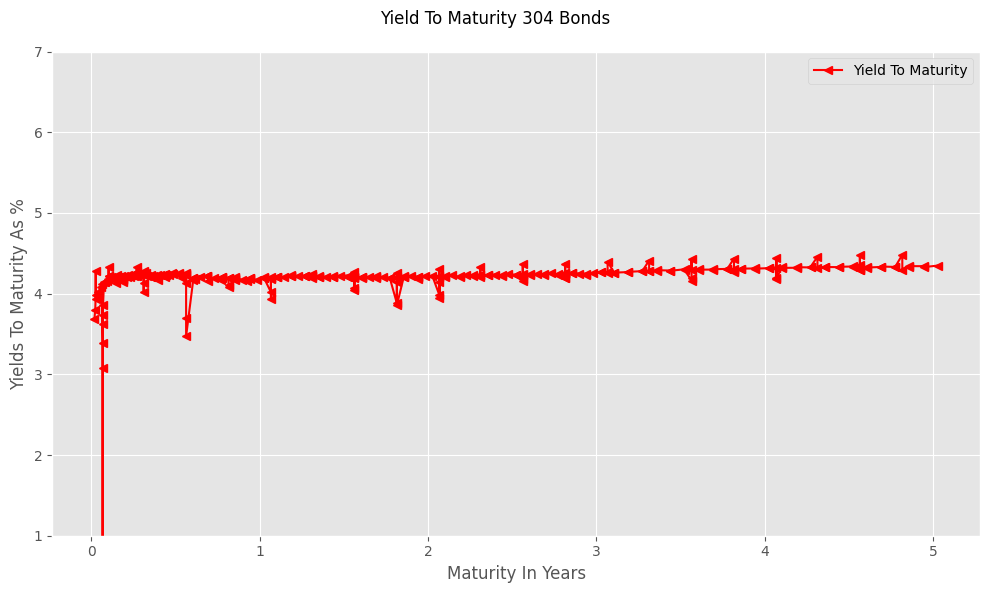

In [ ]:
# Calculate the time to maturity in years for each data point
years=(np.array(bond_data.index,dtype='datetime64[D]')-
       np.datetime64(settlement)).astype(float)/365.25

# Initialize a dictionary to hold plot-saving configurations.
save_config={}
string_date='01/21/2025'

# Set the x-axis and y-axis data for the plot.
#Maturity relative to settlement data
xaxis=years
data=[bond_data['Yield To Maturity']*100]

# Define the file name and folder for the saved plot.
#save_config['File']='Yield To Maturity 304 Fidelity Bonds '+string_date+'.pdf'
#save_config['Folder']=folder

# Attempt to extract the plot title from the file name.
try:
    title = save_config['File Name'][:-4]

#'File' key not found or string is too short), set a default title.
except:
    title = 'Yield To Maturity 304 Bonds'

# Define labels for the data series, y-axis, and x-axis.
#title_string=save_config['File'][:-4]
series=['Yield To Maturity']
ylabel='Yields To Maturity As %'
xlabel='Maturity In Years'

# Set plot aesthetics: marker styles, y-axis limits, figure size, and color.
markers='<'
ylim=[1,7]
size=(10,6)
# Define colors as red
colors='r'

# Call the plotting function with all the prepared data and configurations
one_y_axis(xaxis, data, title, series, xlabel, ylabel, markers, size, ylim,
           save_config=save_config,colors=colors)

## Comparing continuous compounded yield to maturity to U.S. Treasury par yields

Our calculation of yield to maturity assumes continuous compounding.  The U.S.Treasury calculation of par yield assumes discrete compounding.  As result, there is a discrepancy between our calculations of yield to maturity and the U.S. Treasury calculation of par yields.  

$$e^{\text{ytm}} = (1 +\frac{\text{par yield}}{2})^{2}$$

$$\text{ytm} = 2\times ln(1 +\frac{\text{par yield}}{2})$$


## <span style="text-align: left; color:green; font-family: 'Franklin Gothic Medium', sans-serif; margin-top: 1.0em; margin-bottom: 0em; font-style: italic;">Chapter Exercise</span>
<span style="text-align: left; color:green; font-family: 'Franklin Gothic Medium', sans-serif; margin-top: 0; margin-bottom: 0.5em; font-style: italic;
"><big></big>
</span>


<div style="background-color:LightGray;
    border-left: 12px solid green;
    font-family: 'Garamond', serif;
    font-size: 17px;
    line-height: 1.5;
    padding: 15px">
<br>

Calculate the yield to maturity for the following bonds:


|Maturity|Coupon|Clean Price|
|-------|-------|-----------|
|&nbsp;&nbsp;&nbsp;June 30$^{st}$ 2035|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4.375|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;\$100|
|&nbsp;&nbsp;&nbsp;October 31$^{th}$ 2050|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4.125|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;\$95|
|&nbsp;&nbsp;&nbsp;January 31$^{th}$ 2040|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.500|&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;\$65|

Assume that the settlement date is January 31$^{st}$ 2026
</div>

## <font color='green'>Take a deeper dive with AI</font>


#### Some suggestions to get you started with Gemini.

1.   **Are par yields the same as yields to maturity?**

2.   **How does a bond's coupon affect the difference between the bond's yield to maturity and the realized rate of return from holding the bond until it matures?**

3.  **What's the relation between a continuous compounded yield to maturity and a discretely compounded par yield?**

#### [Copy and paste the questions here](https://gemini.google.com)